# Constraint Based 3D Self Assembly Extension

This notebook extends the previous minimal complexity self assembly notebook into a simplified three dimensional voxel based model.

The goal is not to fully reproduce the SAT based design pipeline from the research paper yet. Instead, this notebook builds an educational computational model that helps explore how simple 3D target structures can be represented, how building block interactions can be defined, and how reduced design strategies can be compared against fully addressable designs.

This work is inspired by the idea that self assembling systems can often be designed using fewer unique building blocks than the total number of positions in the target structure. This is important because reducing the number of unique components may lower design complexity, fabrication cost, and experimental difficulty.

The notebook focuses on:

- Representing 3D target shapes using voxel coordinates
- Defining neighbor relationships between cubes
- Creating a fully addressable design
- Creating a simple reduced complexity design
- Comparing the number of species and patch pairs required
- Testing a simplified stochastic assembly process
- Discussing future extensions toward SAT based design and DNA nanotechnology tools such as oxDNA and oxView

## Connection to the Research Paper

The referenced paper studies how arbitrary finite three dimensional structures can be designed to self assemble using building blocks with directional interactions. A key idea is the comparison between fully addressable designs, where every building block is unique, and minimal complexity designs, where fewer species and interaction types are used.

In the full research pipeline, the inverse design problem is formulated using SAT based constraints and then tested using stochastic assembly and patchy particle simulations. This notebook uses a much simpler version of that idea. It represents target structures as voxel based shapes and compares how many unique building block types are needed under different design strategies.

This simplified approach is useful as a first step because it makes the core computational ideas easier to understand before moving toward a real SAT solver or molecular simulation framework.

In [1]:
# ============================================================
# Step 1: Import required libraries
# ============================================================

# What I am doing:
# I am importing the basic Python libraries needed for this notebook.
# NumPy will help with coordinate handling, pandas will help summarize
# design complexity results, and matplotlib will be used for simple 3D
# visualization of voxel based target structures.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
import random

## Step 2: Define Simple 3D Target Shapes

In this step, I define small three dimensional target structures using voxel coordinates. Each voxel represents one cube shaped building block in the final assembled structure.

A coordinate is written as:

`(x, y, z)`

where `x`, `y`, and `z` describe the position of a cube in a 3D grid.

Starting with simple shapes is useful because it allows the model to focus on the logic of connectivity and building block reduction before moving toward larger or more realistic structures.

In [2]:
# ============================================================
# Step 2: Define simple 3D target shapes
# ============================================================

# What I am doing:
# I am defining a few small 3D target shapes using voxel coordinates.
# Each coordinate represents one cube in the target structure.
# These shapes will later be used to build adjacency relationships,
# define patch interactions, and compare different design strategies.

def make_cube_2x2x2():
    """
    Creates a solid 2 x 2 x 2 cube.
    Total voxels: 8
    """
    return [(x, y, z) for x in range(2) for y in range(2) for z in range(2)]


def make_3d_l_shape():
    """
    Creates a simple 3D L shaped structure.
    This shape is intentionally small and asymmetric.
    """
    return [
        (0, 0, 0),
        (1, 0, 0),
        (2, 0, 0),
        (0, 1, 0),
        (0, 2, 0),
        (0, 0, 1),
        (0, 0, 2)
    ]


def make_staircase_shape():
    """
    Creates a simple 3D staircase like structure.
    """
    return [
        (0, 0, 0),
        (1, 0, 0),
        (1, 1, 0),
        (2, 1, 0),
        (2, 1, 1),
        (3, 1, 1)
    ]


# Store all target shapes in one dictionary for easy testing
target_shapes = {
    "2x2x2 Cube": make_cube_2x2x2(),
    "3D L Shape": make_3d_l_shape(),
    "Staircase": make_staircase_shape()
}

# Display the number of voxels in each shape
for shape_name, voxels in target_shapes.items():
    print(f"{shape_name}: {len(voxels)} voxels")
    print(voxels)
    print()

2x2x2 Cube: 8 voxels
[(0, 0, 0), (0, 0, 1), (0, 1, 0), (0, 1, 1), (1, 0, 0), (1, 0, 1), (1, 1, 0), (1, 1, 1)]

3D L Shape: 7 voxels
[(0, 0, 0), (1, 0, 0), (2, 0, 0), (0, 1, 0), (0, 2, 0), (0, 0, 1), (0, 0, 2)]

Staircase: 6 voxels
[(0, 0, 0), (1, 0, 0), (1, 1, 0), (2, 1, 0), (2, 1, 1), (3, 1, 1)]



## Step 3: Visualize the 3D Target Shapes

In this step, I create a simple visualization function for the voxel based target structures.

This is important because self assembly design is easier to understand when the target structure can be inspected visually. Each cube in the plot represents one building block position in the final assembled object.

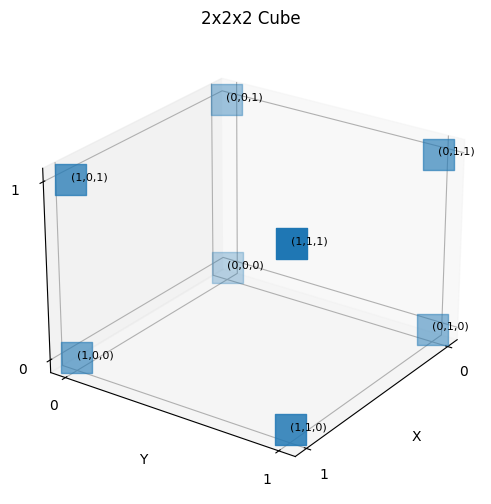

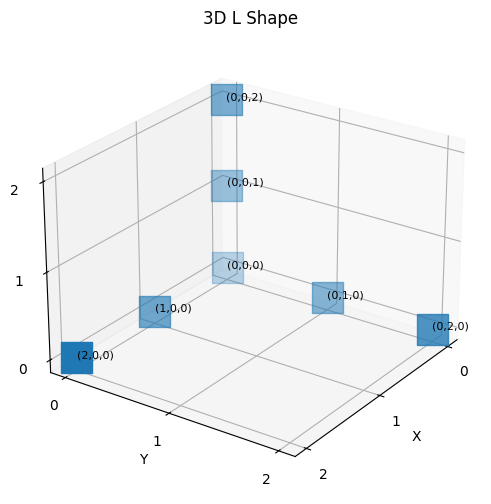

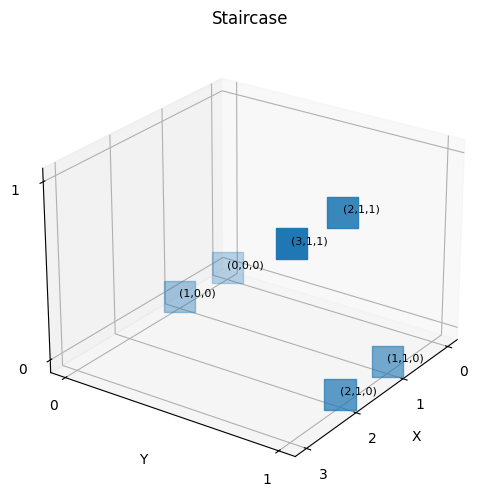

In [3]:
# ============================================================
# Step 3: Visualize 3D target shapes
# ============================================================

# What I am doing:
# I am creating a reusable 3D plotting function for voxel based shapes.
# This helps visually inspect each target structure before building
# adjacency rules and design strategies.

def plot_voxel_shape(voxels, title="3D Target Shape"):
    """
    Plots a voxel based 3D shape from a list of (x, y, z) coordinates.
    """
    voxels = np.array(voxels)

    x = voxels[:, 0]
    y = voxels[:, 1]
    z = voxels[:, 2]

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(x, y, z, s=500, marker="s")

    # Add coordinate labels to each voxel
    for xi, yi, zi in voxels:
        ax.text(xi, yi, zi, f"({xi},{yi},{zi})", fontsize=8)

    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    ax.set_xticks(range(int(x.min()), int(x.max()) + 1))
    ax.set_yticks(range(int(y.min()), int(y.max()) + 1))
    ax.set_zticks(range(int(z.min()), int(z.max()) + 1))

    ax.view_init(elev=25, azim=35)
    plt.show()


# Visualize all target shapes
for shape_name, voxels in target_shapes.items():
    plot_voxel_shape(voxels, title=shape_name)

## Step 4: Build Neighbor and Adjacency Rules

In this step, I identify which cubes are directly connected to each other in each 3D target shape.

For a cubic voxel model, each cube can have up to six possible neighbors:

- +x and -x
- +y and -y
- +z and -z

These directions represent the possible patch locations on a cube shaped building block. If two voxels are adjacent, then the final design needs a compatible patch interaction between those two positions.

In [4]:
# ============================================================
# Step 4: Build neighbor and adjacency rules
# ============================================================

# What I am doing:
# I am defining the six possible directions in a cubic lattice.
# Then I am checking which voxel positions in each target shape
# are directly adjacent. These adjacency relationships represent
# the bonds or patch connections needed for self assembly.

DIRECTIONS = {
    "+x": (1, 0, 0),
    "-x": (-1, 0, 0),
    "+y": (0, 1, 0),
    "-y": (0, -1, 0),
    "+z": (0, 0, 1),
    "-z": (0, 0, -1)
}

OPPOSITE_DIRECTIONS = {
    "+x": "-x",
    "-x": "+x",
    "+y": "-y",
    "-y": "+y",
    "+z": "-z",
    "-z": "+z"
}


def find_adjacencies(voxels):
    """
    Finds all direct neighbor relationships in a voxel shape.

    Returns a list of adjacency records:
    voxel A, direction from A to B, voxel B, and opposite direction.
    """
    voxel_set = set(voxels)
    adjacencies = []

    for voxel in voxels:
        x, y, z = voxel

        for direction_name, offset in DIRECTIONS.items():
            dx, dy, dz = offset
            neighbor = (x + dx, y + dy, z + dz)

            if neighbor in voxel_set:
                # To avoid duplicate bonds, only store one ordering
                if voxel < neighbor:
                    adjacencies.append({
                        "voxel_A": voxel,
                        "direction_A_to_B": direction_name,
                        "voxel_B": neighbor,
                        "direction_B_to_A": OPPOSITE_DIRECTIONS[direction_name]
                    })

    return adjacencies


# Build adjacency information for all target shapes
adjacency_by_shape = {}

for shape_name, voxels in target_shapes.items():
    adjacencies = find_adjacencies(voxels)
    adjacency_by_shape[shape_name] = adjacencies

    print(f"{shape_name}")
    print(f"Number of voxels: {len(voxels)}")
    print(f"Number of required bonds: {len(adjacencies)}")
    print("-" * 50)

    display(pd.DataFrame(adjacencies))

2x2x2 Cube
Number of voxels: 8
Number of required bonds: 12
--------------------------------------------------


,voxel_A,direction_A_to_B,voxel_B,direction_B_to_A
0,"(0, 0, 0)",+x,"(1, 0, 0)",-x
1,"(0, 0, 0)",+y,"(0, 1, 0)",-y
2,"(0, 0, 0)",+z,"(0, 0, 1)",-z
3,"(0, 0, 1)",+x,"(1, 0, 1)",-x
4,"(0, 0, 1)",+y,"(0, 1, 1)",-y
5,"(0, 1, 0)",+x,"(1, 1, 0)",-x
6,"(0, 1, 0)",+z,"(0, 1, 1)",-z
7,"(0, 1, 1)",+x,"(1, 1, 1)",-x
8,"(1, 0, 0)",+y,"(1, 1, 0)",-y
9,"(1, 0, 0)",+z,"(1, 0, 1)",-z


3D L Shape
Number of voxels: 7
Number of required bonds: 6
--------------------------------------------------


,voxel_A,direction_A_to_B,voxel_B,direction_B_to_A
0,"(0, 0, 0)",+x,"(1, 0, 0)",-x
1,"(0, 0, 0)",+y,"(0, 1, 0)",-y
2,"(0, 0, 0)",+z,"(0, 0, 1)",-z
3,"(1, 0, 0)",+x,"(2, 0, 0)",-x
4,"(0, 1, 0)",+y,"(0, 2, 0)",-y
5,"(0, 0, 1)",+z,"(0, 0, 2)",-z


Staircase
Number of voxels: 6
Number of required bonds: 5
--------------------------------------------------


,voxel_A,direction_A_to_B,voxel_B,direction_B_to_A
0,"(0, 0, 0)",+x,"(1, 0, 0)",-x
1,"(1, 0, 0)",+y,"(1, 1, 0)",-y
2,"(1, 1, 0)",+x,"(2, 1, 0)",-x
3,"(2, 1, 0)",+z,"(2, 1, 1)",-z
4,"(2, 1, 1)",+x,"(3, 1, 1)",-x


## Step 5: Create a Fully Addressable Design

In this step, I create a fully addressable design for each target shape.

A fully addressable design means that every voxel position gets its own unique building block species. Also, every required bond gets its own unique complementary patch pair.

This is the highest complexity design strategy, but it is useful as a baseline because it directly encodes the full target structure without trying to reduce the number of building block types.

In [5]:
# ============================================================
# Step 5: Create a fully addressable design
# ============================================================

# What I am doing:
# I am assigning a unique building block species to every voxel.
# I am also assigning a unique complementary patch pair to every bond.
# This creates the maximum complexity design, which will be used later
# as a baseline for comparison against reduced complexity designs.

def create_fully_addressable_design(voxels, adjacencies):
    """
    Creates a fully addressable design for a voxel shape.

    In this design:
    - Every voxel gets a unique species.
    - Every bond gets a unique complementary patch pair.
    - Patch colors are assigned based on the direction of each bond.
    """

    # Assign one unique species to each voxel
    species_map = {
        voxel: f"S{i + 1}"
        for i, voxel in enumerate(sorted(voxels))
    }

    # Initialize patch table for each species
    species_patches = {
        species: {direction: None for direction in DIRECTIONS.keys()}
        for species in species_map.values()
    }

    # Store complementary patch interactions
    interaction_pairs = []

    # Assign one unique complementary patch pair per required bond
    for bond_id, bond in enumerate(adjacencies, start=1):
        voxel_A = bond["voxel_A"]
        voxel_B = bond["voxel_B"]
        direction_A = bond["direction_A_to_B"]
        direction_B = bond["direction_B_to_A"]

        species_A = species_map[voxel_A]
        species_B = species_map[voxel_B]

        patch_A = f"C{bond_id}a"
        patch_B = f"C{bond_id}b"

        species_patches[species_A][direction_A] = patch_A
        species_patches[species_B][direction_B] = patch_B

        interaction_pairs.append({
            "bond_id": bond_id,
            "species_A": species_A,
            "voxel_A": voxel_A,
            "patch_A": patch_A,
            "direction_A": direction_A,
            "species_B": species_B,
            "voxel_B": voxel_B,
            "patch_B": patch_B,
            "direction_B": direction_B
        })

    # Convert species patch information into a table
    species_table = []

    for voxel, species in species_map.items():
        row = {
            "voxel": voxel,
            "species": species
        }

        for direction in DIRECTIONS.keys():
            row[direction] = species_patches[species][direction]

        species_table.append(row)

    species_table = pd.DataFrame(species_table)
    interaction_table = pd.DataFrame(interaction_pairs)

    summary = {
        "num_voxels": len(voxels),
        "num_species": len(species_map),
        "num_required_bonds": len(adjacencies),
        "num_patch_colors": len(adjacencies) * 2,
        "num_patch_pairs": len(adjacencies)
    }

    return species_table, interaction_table, summary


# Create fully addressable designs for all target shapes
fully_addressable_results = {}

for shape_name, voxels in target_shapes.items():
    adjacencies = adjacency_by_shape[shape_name]

    species_table, interaction_table, summary = create_fully_addressable_design(
        voxels,
        adjacencies
    )

    fully_addressable_results[shape_name] = {
        "species_table": species_table,
        "interaction_table": interaction_table,
        "summary": summary
    }

    print("=" * 70)
    print(f"Fully Addressable Design: {shape_name}")
    print("=" * 70)
    print("Summary:")
    print(summary)
    print()

    print("Species and Patch Table:")
    display(species_table)

    print("Complementary Patch Interaction Table:")
    display(interaction_table)

Fully Addressable Design: 2x2x2 Cube
Summary:
{'num_voxels': 8, 'num_species': 8, 'num_required_bonds': 12, 'num_patch_colors': 24, 'num_patch_pairs': 12}

Species and Patch Table:


,voxel,species,+x,-x,+y,-y,+z,-z
0,"(0, 0, 0)",S1,C1a,None,C2a,None,C3a,None
1,"(0, 0, 1)",S2,C4a,None,C5a,None,None,C3b
2,"(0, 1, 0)",S3,C6a,None,None,C2b,C7a,None
3,"(0, 1, 1)",S4,C8a,None,None,C5b,None,C7b
4,"(1, 0, 0)",S5,None,C1b,C9a,None,C10a,None
5,"(1, 0, 1)",S6,None,C4b,C11a,None,None,C10b
6,"(1, 1, 0)",S7,None,C6b,None,C9b,C12a,None
7,"(1, 1, 1)",S8,None,C8b,None,C11b,None,C12b


Complementary Patch Interaction Table:


,bond_id,species_A,voxel_A,patch_A,direction_A,species_B,voxel_B,patch_B,direction_B
0,1,S1,"(0, 0, 0)",C1a,+x,S5,"(1, 0, 0)",C1b,-x
1,2,S1,"(0, 0, 0)",C2a,+y,S3,"(0, 1, 0)",C2b,-y
2,3,S1,"(0, 0, 0)",C3a,+z,S2,"(0, 0, 1)",C3b,-z
3,4,S2,"(0, 0, 1)",C4a,+x,S6,"(1, 0, 1)",C4b,-x
4,5,S2,"(0, 0, 1)",C5a,+y,S4,"(0, 1, 1)",C5b,-y
5,6,S3,"(0, 1, 0)",C6a,+x,S7,"(1, 1, 0)",C6b,-x
6,7,S3,"(0, 1, 0)",C7a,+z,S4,"(0, 1, 1)",C7b,-z
7,8,S4,"(0, 1, 1)",C8a,+x,S8,"(1, 1, 1)",C8b,-x
8,9,S5,"(1, 0, 0)",C9a,+y,S7,"(1, 1, 0)",C9b,-y
9,10,S5,"(1, 0, 0)",C10a,+z,S6,"(1, 0, 1)",C10b,-z


Fully Addressable Design: 3D L Shape
Summary:
{'num_voxels': 7, 'num_species': 7, 'num_required_bonds': 6, 'num_patch_colors': 12, 'num_patch_pairs': 6}

Species and Patch Table:


...

,bond_id,species_A,voxel_A,patch_A,direction_A,species_B,voxel_B,patch_B,direction_B
0,1,S1,"(0, 0, 0)",C1a,+x,S6,"(1, 0, 0)",C1b,-x
1,2,S1,"(0, 0, 0)",C2a,+y,S4,"(0, 1, 0)",C2b,-y
2,3,S1,"(0, 0, 0)",C3a,+z,S2,"(0, 0, 1)",C3b,-z
3,4,S6,"(1, 0, 0)",C4a,+x,S7,"(2, 0, 0)",C4b,-x
4,5,S4,"(0, 1, 0)",C5a,+y,S5,"(0, 2, 0)",C5b,-y
5,6,S2,"(0, 0, 1)",C6a,+z,S3,"(0, 0, 2)",C6b,-z


Fully Addressable Design: Staircase
Summary:
{'num_voxels': 6, 'num_species': 6, 'num_required_bonds': 5, 'num_patch_colors': 10, 'num_patch_pairs': 5}

Species and Patch Table:


,voxel,species,+x,-x,+y,-y,+z,-z
0,"(0, 0, 0)",S1,C1a,None,None,None,None,None
1,"(1, 0, 0)",S2,None,C1b,C2a,None,None,None
2,"(1, 1, 0)",S3,C3a,None,None,C2b,None,None
3,"(2, 1, 0)",S4,None,C3b,None,None,C4a,None
4,"(2, 1, 1)",S5,C5a,None,None,None,None,C4b
5,"(3, 1, 1)",S6,None,C5b,None,None,None,None


Complementary Patch Interaction Table:


,bond_id,species_A,voxel_A,patch_A,direction_A,species_B,voxel_B,patch_B,direction_B
0,1,S1,"(0, 0, 0)",C1a,+x,S2,"(1, 0, 0)",C1b,-x
1,2,S2,"(1, 0, 0)",C2a,+y,S3,"(1, 1, 0)",C2b,-y
2,3,S3,"(1, 1, 0)",C3a,+x,S4,"(2, 1, 0)",C3b,-x
3,4,S4,"(2, 1, 0)",C4a,+z,S5,"(2, 1, 1)",C4b,-z
4,5,S5,"(2, 1, 1)",C5a,+x,S6,"(3, 1, 1)",C5b,-x


## Step 6: Create a Simple Reduced Complexity Design

In this step, I create a simplified reduced complexity design.

Instead of assigning a unique building block species to every voxel, this strategy groups voxels that have the same local connectivity pattern. For example, two cubes may be treated as the same species if they need patches in the same directions.

This is not a full SAT based inverse design solver. It is a simple heuristic reduction method that helps illustrate the main idea: some target structures may be represented with fewer unique building block types than the number of positions in the structure.

The goal here is to compare this reduced strategy against the fully addressable baseline.

In [6]:
# ============================================================
# Step 6: Create a simple reduced complexity design
# ============================================================

# What I am doing:
# I am creating a simplified reduced design strategy.
# Instead of giving every voxel a unique species, I group voxels
# by their local patch direction pattern.
#
# Important limitation:
# This is a heuristic reduction method, not a true SAT solver.
# It does not guarantee that the reduced design uniquely assembles
# only the target shape. It is mainly used here to understand how
# complexity can be reduced in a first-pass educational model.

def get_voxel_patch_directions(voxel, adjacencies):
    """
    Finds which directions from a voxel require patches.
    """
    required_directions = []

    for bond in adjacencies:
        if bond["voxel_A"] == voxel:
            required_directions.append(bond["direction_A_to_B"])
        elif bond["voxel_B"] == voxel:
            required_directions.append(bond["direction_B_to_A"])

    return tuple(sorted(required_directions))


def create_reduced_complexity_design(voxels, adjacencies):
    """
    Creates a simplified reduced complexity design.

    In this design:
    - Voxels with the same local patch direction pattern are grouped.
    - Each group becomes one building block species.
    - Patch colors are assigned by direction pair rather than by each bond.
    """

    # Find local patch direction signature for each voxel
    voxel_signatures = {
        voxel: get_voxel_patch_directions(voxel, adjacencies)
        for voxel in sorted(voxels)
    }

    # Group voxels by identical local signature
    signature_to_species = {}
    species_counter = 1

    for signature in sorted(set(voxel_signatures.values())):
        signature_to_species[signature] = f"R{species_counter}"
        species_counter += 1

    # Assign species to voxels
    species_map = {
        voxel: signature_to_species[signature]
        for voxel, signature in voxel_signatures.items()
    }

    # Define generic complementary patch pairs for directions
    direction_patch_pairs = {
        "+x": "X_plus",
        "-x": "X_minus",
        "+y": "Y_plus",
        "-y": "Y_minus",
        "+z": "Z_plus",
        "-z": "Z_minus"
    }

    complementary_pairs = {
        "X_plus": "X_minus",
        "X_minus": "X_plus",
        "Y_plus": "Y_minus",
        "Y_minus": "Y_plus",
        "Z_plus": "Z_minus",
        "Z_minus": "Z_plus"
    }

    # Build species patch table
    species_rows = []

    for signature, species in signature_to_species.items():
        row = {
            "species": species,
            "local_patch_signature": signature,
            "used_by_voxels": [
                voxel for voxel, voxel_signature in voxel_signatures.items()
                if voxel_signature == signature
            ]
        }

        for direction in DIRECTIONS.keys():
            if direction in signature:
                row[direction] = direction_patch_pairs[direction]
            else:
                row[direction] = None

        species_rows.append(row)

    species_table = pd.DataFrame(species_rows)

    # Build voxel assignment table
    voxel_assignment_rows = []

    for voxel in sorted(voxels):
        voxel_assignment_rows.append({
            "voxel": voxel,
            "assigned_species": species_map[voxel],
            "local_patch_signature": voxel_signatures[voxel]
        })

    voxel_assignment_table = pd.DataFrame(voxel_assignment_rows)

    # Build interaction table
    interaction_table = pd.DataFrame([
        {
            "patch_A": "X_plus",
            "patch_B": "X_minus",
            "axis": "x"
        },
        {
            "patch_A": "Y_plus",
            "patch_B": "Y_minus",
            "axis": "y"
        },
        {
            "patch_A": "Z_plus",
            "patch_B": "Z_minus",
            "axis": "z"
        }
    ])

    # Count only patch colors that are actually used
    used_patch_colors = set()

    for signature in voxel_signatures.values():
        for direction in signature:
            used_patch_colors.add(direction_patch_pairs[direction])

    summary = {
        "num_voxels": len(voxels),
        "num_species": len(signature_to_species),
        "num_required_bonds": len(adjacencies),
        "num_patch_colors": len(used_patch_colors),
        "num_patch_pairs": len(used_patch_colors) // 2
    }

    return species_table, voxel_assignment_table, interaction_table, summary


# Create reduced complexity designs for all target shapes
reduced_complexity_results = {}

for shape_name, voxels in target_shapes.items():
    adjacencies = adjacency_by_shape[shape_name]

    species_table, voxel_assignment_table, interaction_table, summary = create_reduced_complexity_design(
        voxels,
        adjacencies
    )

    reduced_complexity_results[shape_name] = {
        "species_table": species_table,
        "voxel_assignment_table": voxel_assignment_table,
        "interaction_table": interaction_table,
        "summary": summary
    }

    print("=" * 70)
    print(f"Reduced Complexity Design: {shape_name}")
    print("=" * 70)
    print("Summary:")
    print(summary)
    print()

    print("Reduced Species Table:")
    display(species_table)

    print("Voxel to Species Assignment:")
    display(voxel_assignment_table)

    print("Generic Complementary Patch Interaction Table:")
    display(interaction_table)

Reduced Complexity Design: 2x2x2 Cube
Summary:
{'num_voxels': 8, 'num_species': 8, 'num_required_bonds': 12, 'num_patch_colors': 6, 'num_patch_pairs': 3}

Reduced Species Table:


,species,local_patch_signature,used_by_voxels,+x,-x,+y,-y,+z,-z
0,R1,"(+x, +y, +z)","[(0, 0, 0)]",X_plus,None,Y_plus,None,Z_plus,None
1,R2,"(+x, +y, -z)","[(0, 0, 1)]",X_plus,None,Y_plus,None,None,Z_minus
2,R3,"(+x, +z, -y)","[(0, 1, 0)]",X_plus,None,None,Y_minus,Z_plus,None
3,R4,"(+x, -y, -z)","[(0, 1, 1)]",X_plus,None,None,Y_minus,None,Z_minus
4,R5,"(+y, +z, -x)","[(1, 0, 0)]",None,X_minus,Y_plus,None,Z_plus,None
5,R6,"(+y, -x, -z)","[(1, 0, 1)]",None,X_minus,Y_plus,None,None,Z_minus
6,R7,"(+z, -x, -y)","[(1, 1, 0)]",None,X_minus,None,Y_minus,Z_plus,None
7,R8,"(-x, -y, -z)","[(1, 1, 1)]",None,X_minus,None,Y_minus,None,Z_minus


Voxel to Species Assignment:


,voxel,assigned_species,local_patch_signature
0,"(0, 0, 0)",R1,"(+x, +y, +z)"
1,"(0, 0, 1)",R2,"(+x, +y, -z)"
2,"(0, 1, 0)",R3,"(+x, +z, -y)"
3,"(0, 1, 1)",R4,"(+x, -y, -z)"
4,"(1, 0, 0)",R5,"(+y, +z, -x)"
5,"(1, 0, 1)",R6,"(+y, -x, -z)"
6,"(1, 1, 0)",R7,"(+z, -x, -y)"
7,"(1, 1, 1)",R8,"(-x, -y, -z)"


Generic Complementary Patch Interaction Table:


...

,species,local_patch_signature,used_by_voxels,+x,-x,+y,-y,+z,-z
0,R1,"(+x,)","[(0, 0, 0)]",X_plus,None,None,None,None,None
1,R2,"(+x, -y)","[(1, 1, 0)]",X_plus,None,None,Y_minus,None,None
2,R3,"(+x, -z)","[(2, 1, 1)]",X_plus,None,None,None,None,Z_minus
3,R4,"(+y, -x)","[(1, 0, 0)]",None,X_minus,Y_plus,None,None,None
4,R5,"(+z, -x)","[(2, 1, 0)]",None,X_minus,None,None,Z_plus,None
5,R6,"(-x,)","[(3, 1, 1)]",None,X_minus,None,None,None,None


Voxel to Species Assignment:


,voxel,assigned_species,local_patch_signature
0,"(0, 0, 0)",R1,"(+x,)"
1,"(1, 0, 0)",R4,"(+y, -x)"
2,"(1, 1, 0)",R2,"(+x, -y)"
3,"(2, 1, 0)",R5,"(+z, -x)"
4,"(2, 1, 1)",R3,"(+x, -z)"
5,"(3, 1, 1)",R6,"(-x,)"


Generic Complementary Patch Interaction Table:


,patch_A,patch_B,axis
0,X_plus,X_minus,x
1,Y_plus,Y_minus,y
2,Z_plus,Z_minus,z


## Step 7: Compare Fully Addressable and Reduced Complexity Designs

In this step, I compare the fully addressable design against the reduced complexity design.

The fully addressable design uses one unique species for every voxel and one unique complementary patch pair for every required bond.

The reduced complexity design groups voxels with similar local patch direction patterns. This can lower the number of unique building block species and patch colors, but it does not guarantee perfect target specificity the way a full SAT based inverse design method would aim to do.

This comparison helps show the tradeoff between design complexity and structural control.

In [7]:
# ============================================================
# Step 7: Compare fully addressable and reduced complexity designs
# ============================================================

# What I am doing:
# I am comparing the maximum complexity design against the reduced
# complexity heuristic design for each target shape.
#
# This helps measure how much the number of species and patch colors
# can be reduced when similar local building block environments are grouped.

comparison_rows = []

for shape_name in target_shapes.keys():
    full_summary = fully_addressable_results[shape_name]["summary"]
    reduced_summary = reduced_complexity_results[shape_name]["summary"]

    full_species = full_summary["num_species"]
    reduced_species = reduced_summary["num_species"]

    full_patch_colors = full_summary["num_patch_colors"]
    reduced_patch_colors = reduced_summary["num_patch_colors"]

    full_patch_pairs = full_summary["num_patch_pairs"]
    reduced_patch_pairs = reduced_summary["num_patch_pairs"]

    species_reduction_percent = 100 * (1 - reduced_species / full_species)
    patch_color_reduction_percent = 100 * (1 - reduced_patch_colors / full_patch_colors)
    patch_pair_reduction_percent = 100 * (1 - reduced_patch_pairs / full_patch_pairs)

    comparison_rows.append({
        "shape": shape_name,
        "num_voxels": full_summary["num_voxels"],
        "num_required_bonds": full_summary["num_required_bonds"],

        "fully_addressable_species": full_species,
        "reduced_species": reduced_species,
        "species_reduction_percent": round(species_reduction_percent, 2),

        "fully_addressable_patch_colors": full_patch_colors,
        "reduced_patch_colors": reduced_patch_colors,
        "patch_color_reduction_percent": round(patch_color_reduction_percent, 2),

        "fully_addressable_patch_pairs": full_patch_pairs,
        "reduced_patch_pairs": reduced_patch_pairs,
        "patch_pair_reduction_percent": round(patch_pair_reduction_percent, 2)
    })

comparison_df = pd.DataFrame(comparison_rows)

display(comparison_df)

,shape,num_voxels,num_required_bonds,fully_addressable_species,reduced_species,species_reduction_percent,fully_addressable_patch_colors,reduced_patch_colors,patch_color_reduction_percent,fully_addressable_patch_pairs,reduced_patch_pairs,patch_pair_reduction_percent
0,2x2x2 Cube,8,12,8,8,0.0,24,6,75.0,12,3,75.0
1,3D L Shape,7,6,7,7,0.0,12,6,50.0,6,3,50.0
2,Staircase,6,5,6,6,0.0,10,6,40.0,5,3,40.0


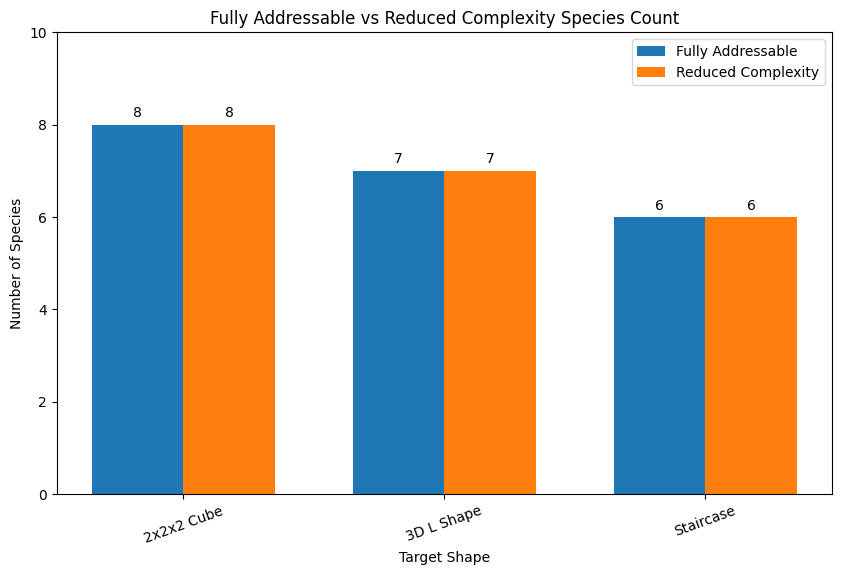

In [12]:
# ============================================================
# Step 7B: Visualize design complexity reduction clearly
# ============================================================

# What I am doing:
# I am plotting the number of species required by the fully addressable
# design and the reduced complexity design.
#
# I am also adding value labels above each bar so that even small or
# equal values are visible in the figure.

x = np.arange(len(comparison_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

full_bars = ax.bar(
    x - width / 2,
    comparison_df["fully_addressable_species"],
    width,
    label="Fully Addressable"
)

reduced_bars = ax.bar(
    x + width / 2,
    comparison_df["reduced_species"],
    width,
    label="Reduced Complexity"
)

ax.set_xlabel("Target Shape")
ax.set_ylabel("Number of Species")
ax.set_title("Fully Addressable vs Reduced Complexity Species Count")
ax.set_xticks(x)
ax.set_xticklabels(comparison_df["shape"], rotation=20)
ax.legend()

# Add labels above bars
for bar in full_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.1,
        int(height),
        ha="center",
        va="bottom"
    )

for bar in reduced_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.1,
        int(height),
        ha="center",
        va="bottom"
    )

ax.set_ylim(0, max(comparison_df["fully_addressable_species"]) + 2)

plt.show()

In [13]:
comparison_df[
    [
        "shape",
        "fully_addressable_species",
        "reduced_species",
        "species_reduction_percent"
    ]
]

,shape,fully_addressable_species,reduced_species,species_reduction_percent
0,2x2x2 Cube,8,8,0.0
1,3D L Shape,7,7,0.0
2,Staircase,6,6,0.0


## Step 8: Simple Stochastic Assembly Test

In this step, I test whether each target shape can be reconstructed through a simplified stochastic assembly process.

The simulation starts from one seed voxel and grows the structure by randomly adding adjacent target voxels. This does not represent full molecular dynamics, thermodynamics, or a true SAT based assembly validation. Instead, it is a lightweight lattice based test that checks whether the target shape can be built through sequential local additions.

This simplified test is useful because it connects the design tables to an assembly process, while keeping the model understandable and computationally small.

In [9]:
# ============================================================
# Step 8: Simple stochastic assembly test
# ============================================================

# What I am doing:
# I am creating a simplified stochastic assembly simulation.
# The model starts from a random seed voxel and grows the target shape
# by randomly adding neighboring voxels that are part of the target.
#
# Important limitation:
# This is a target-guided lattice growth model. It does not search for
# off-target assemblies or kinetic traps. A full research pipeline would
# require SAT based constraints and more detailed simulation methods.

def get_neighbors(voxel):
    """
    Returns the six possible neighboring coordinates of a voxel.
    """
    x, y, z = voxel

    neighbors = []

    for direction_name, offset in DIRECTIONS.items():
        dx, dy, dz = offset
        neighbor = (x + dx, y + dy, z + dz)
        neighbors.append((neighbor, direction_name))

    return neighbors


def run_stochastic_assembly_trial(voxels, max_steps=100):
    """
    Runs one simplified stochastic assembly trial.

    The target is considered successfully assembled if all voxels
    in the target shape are added to the growing cluster.
    """
    target_set = set(voxels)

    # Start from a random seed voxel
    seed = random.choice(list(target_set))
    assembled = set([seed])

    assembly_order = [seed]

    for step in range(max_steps):
        possible_additions = []

        # Find target voxels that are adjacent to the current assembled cluster
        for current_voxel in assembled:
            for neighbor, direction in get_neighbors(current_voxel):
                if neighbor in target_set and neighbor not in assembled:
                    possible_additions.append(neighbor)

        # Remove duplicate possible additions
        possible_additions = list(set(possible_additions))

        # Stop if there is nothing left to add
        if len(possible_additions) == 0:
            break

        # Randomly add one compatible neighboring voxel
        next_voxel = random.choice(possible_additions)
        assembled.add(next_voxel)
        assembly_order.append(next_voxel)

        # Stop early if the target is complete
        if assembled == target_set:
            break

    success = assembled == target_set

    return {
        "success": success,
        "num_assembled": len(assembled),
        "target_size": len(target_set),
        "assembly_order": assembly_order
    }


def run_multiple_assembly_trials(voxels, num_trials=100):
    """
    Runs multiple stochastic assembly trials and summarizes success rate.
    """
    results = []

    for trial in range(num_trials):
        result = run_stochastic_assembly_trial(voxels)
        results.append(result)

    success_count = sum(result["success"] for result in results)
    success_rate = success_count / num_trials

    summary = {
        "num_trials": num_trials,
        "success_count": success_count,
        "success_rate": success_rate,
        "average_assembled_voxels": np.mean([
            result["num_assembled"] for result in results
        ])
    }

    return results, summary


# Run stochastic assembly tests for all target shapes
assembly_test_results = {}

for shape_name, voxels in target_shapes.items():
    results, summary = run_multiple_assembly_trials(voxels, num_trials=100)

    assembly_test_results[shape_name] = {
        "trial_results": results,
        "summary": summary
    }

    print("=" * 70)
    print(f"Stochastic Assembly Test: {shape_name}")
    print("=" * 70)
    print(summary)
    print()

    print("Example assembly order from first trial:")
    print(results[0]["assembly_order"])
    print()

Stochastic Assembly Test: 2x2x2 Cube
{'num_trials': 100, 'success_count': 100, 'success_rate': 1.0, 'average_assembled_voxels': np.float64(8.0)}

Example assembly order from first trial:
[(0, 1, 1), (0, 0, 1), (1, 0, 1), (1, 1, 1), (1, 0, 0), (0, 0, 0), (1, 1, 0), (0, 1, 0)]

Stochastic Assembly Test: 3D L Shape
{'num_trials': 100, 'success_count': 100, 'success_rate': 1.0, 'average_assembled_voxels': np.float64(7.0)}

Example assembly order from first trial:
[(0, 2, 0), (0, 1, 0), (0, 0, 0), (0, 0, 1), (0, 0, 2), (1, 0, 0), (2, 0, 0)]

Stochastic Assembly Test: Staircase
{'num_trials': 100, 'success_count': 100, 'success_rate': 1.0, 'average_assembled_voxels': np.float64(6.0)}

Example assembly order from first trial:
[(1, 0, 0), (1, 1, 0), (0, 0, 0), (2, 1, 0), (2, 1, 1), (3, 1, 1)]



## Step 9: Summarize Assembly Test Results

In this step, I summarize the stochastic assembly results for each target shape.

The goal is to connect the design complexity results from the previous steps with the simplified assembly behavior. Since this model is target guided and does not include off target growth, most small connected shapes are expected to assemble successfully.

The main value of this step is that it gives a clean summary table showing:

- Target shape size
- Number of required bonds
- Fully addressable species count
- Reduced species count
- Species reduction percentage
- Stochastic assembly success rate

In [10]:
# ============================================================
# Step 9: Summarize assembly and design results
# ============================================================

# What I am doing:
# I am combining the design complexity comparison with the simplified
# stochastic assembly results. This gives one clean summary table that
# can be used to discuss the overall findings from the notebook.

final_summary_rows = []

for shape_name in target_shapes.keys():
    design_row = comparison_df[comparison_df["shape"] == shape_name].iloc[0]
    assembly_summary = assembly_test_results[shape_name]["summary"]

    final_summary_rows.append({
        "shape": shape_name,
        "num_voxels": design_row["num_voxels"],
        "num_required_bonds": design_row["num_required_bonds"],
        "fully_addressable_species": design_row["fully_addressable_species"],
        "reduced_species": design_row["reduced_species"],
        "species_reduction_percent": design_row["species_reduction_percent"],
        "fully_addressable_patch_colors": design_row["fully_addressable_patch_colors"],
        "reduced_patch_colors": design_row["reduced_patch_colors"],
        "patch_color_reduction_percent": design_row["patch_color_reduction_percent"],
        "assembly_success_rate": assembly_summary["success_rate"],
        "average_assembled_voxels": assembly_summary["average_assembled_voxels"]
    })

final_summary_df = pd.DataFrame(final_summary_rows)

display(final_summary_df)

,shape,num_voxels,num_required_bonds,fully_addressable_species,reduced_species,species_reduction_percent,fully_addressable_patch_colors,reduced_patch_colors,patch_color_reduction_percent,assembly_success_rate,average_assembled_voxels
0,2x2x2 Cube,8,12,8,8,0.0,24,6,75.0,1.0,8.0
1,3D L Shape,7,6,7,7,0.0,12,6,50.0,1.0,7.0
2,Staircase,6,5,6,6,0.0,10,6,40.0,1.0,6.0


/tmp/ipykernel_15762/2323665543.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(final_summary_df["shape"], rotation=20)


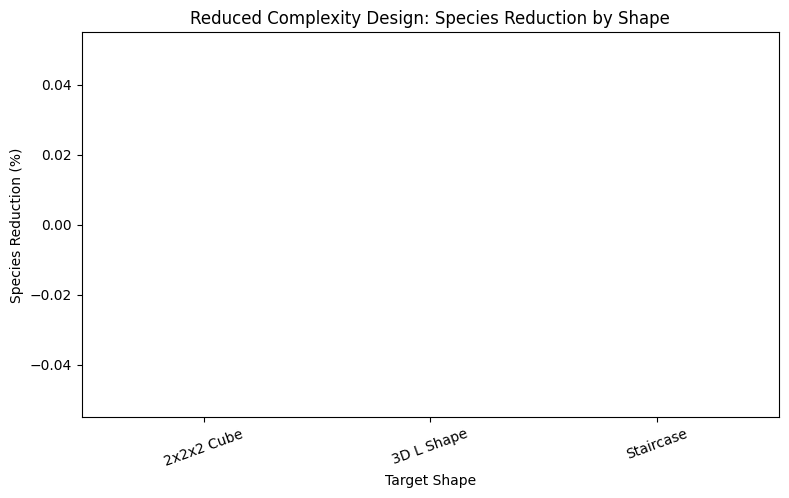

/tmp/ipykernel_15762/2323665543.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(final_summary_df["shape"], rotation=20)


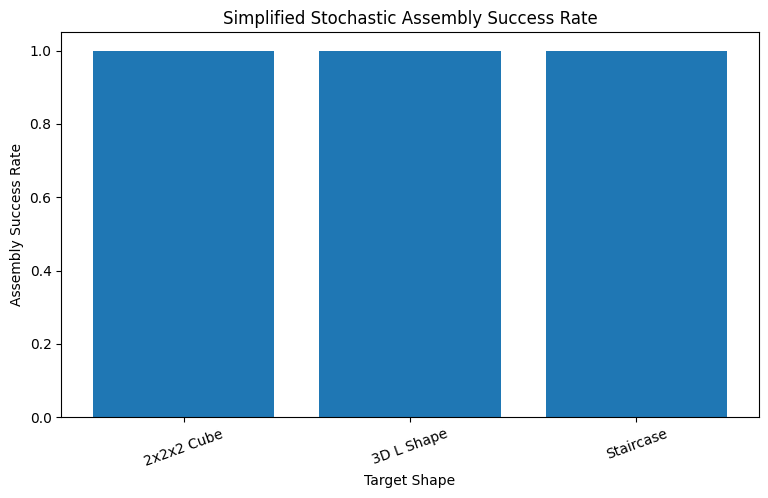

In [14]:
# ============================================================
# Step 9B: Visualize species reduction and assembly success
# ============================================================

# What I am doing:
# I am creating two simple plots:
# 1. Species reduction percentage for each target shape
# 2. Assembly success rate for each target shape
#
# These plots help communicate the main results more clearly.

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    final_summary_df["shape"],
    final_summary_df["species_reduction_percent"]
)

ax.set_xlabel("Target Shape")
ax.set_ylabel("Species Reduction (%)")
ax.set_title("Reduced Complexity Design: Species Reduction by Shape")
ax.set_xticklabels(final_summary_df["shape"], rotation=20)

plt.show()


fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    final_summary_df["shape"],
    final_summary_df["assembly_success_rate"]
)

ax.set_xlabel("Target Shape")
ax.set_ylabel("Assembly Success Rate")
ax.set_title("Simplified Stochastic Assembly Success Rate")
ax.set_ylim(0, 1.05)
ax.set_xticklabels(final_summary_df["shape"], rotation=20)

plt.show()

In [15]:
display(final_summary_df)

,shape,num_voxels,num_required_bonds,fully_addressable_species,reduced_species,species_reduction_percent,fully_addressable_patch_colors,reduced_patch_colors,patch_color_reduction_percent,assembly_success_rate,average_assembled_voxels
0,2x2x2 Cube,8,12,8,8,0.0,24,6,75.0,1.0,8.0
1,3D L Shape,7,6,7,7,0.0,12,6,50.0,1.0,7.0
2,Staircase,6,5,6,6,0.0,10,6,40.0,1.0,6.0


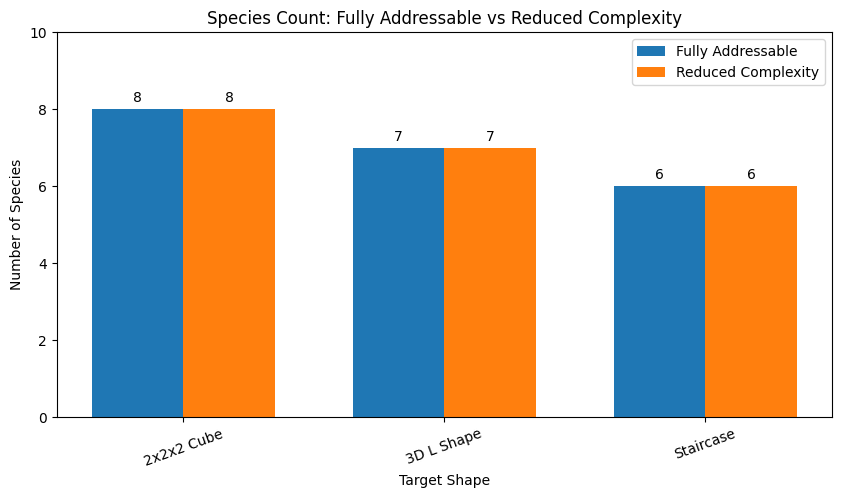

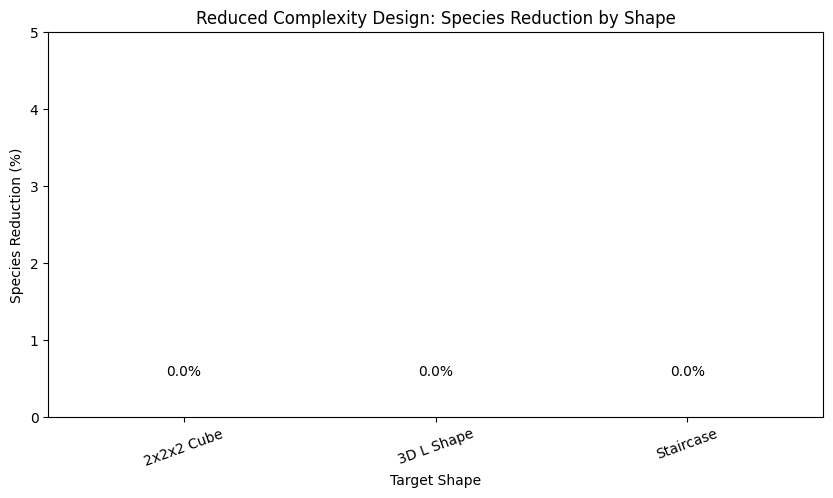

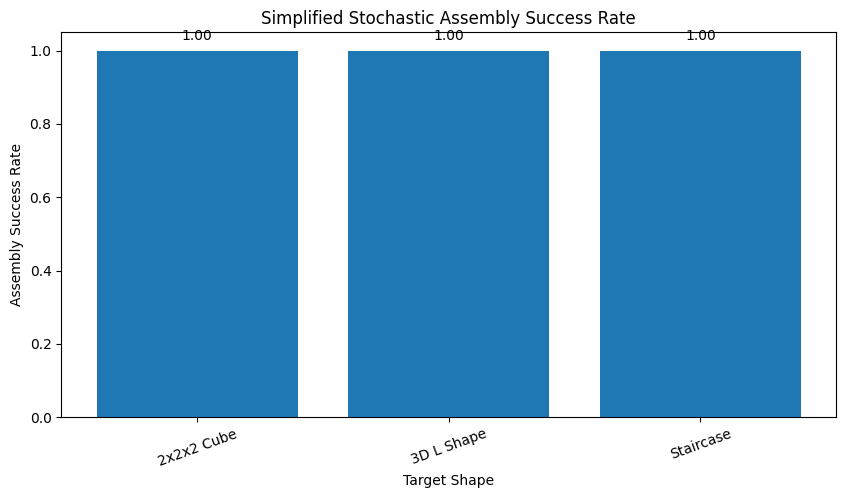

In [16]:
# ============================================================
# Step 9B: Visualize species counts and assembly success clearly
# ============================================================

# What I am doing:
# I am visualizing the final results in a clearer way.
# Since the current reduced design may produce 0 percent reduction
# for some small shapes, I first plot the actual species counts.
# Then I plot the stochastic assembly success rate.

x = np.arange(len(final_summary_df))
width = 0.35

# ------------------------------------------------------------
# Plot 1: Fully addressable vs reduced species count
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

full_bars = ax.bar(
    x - width / 2,
    final_summary_df["fully_addressable_species"],
    width,
    label="Fully Addressable"
)

reduced_bars = ax.bar(
    x + width / 2,
    final_summary_df["reduced_species"],
    width,
    label="Reduced Complexity"
)

ax.set_xlabel("Target Shape")
ax.set_ylabel("Number of Species")
ax.set_title("Species Count: Fully Addressable vs Reduced Complexity")
ax.set_xticks(x)
ax.set_xticklabels(final_summary_df["shape"], rotation=20)
ax.legend()

# Add number labels above bars
for bars in [full_bars, reduced_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.1,
            f"{int(height)}",
            ha="center",
            va="bottom"
        )

ax.set_ylim(
    0,
    max(
        final_summary_df["fully_addressable_species"].max(),
        final_summary_df["reduced_species"].max()
    ) + 2
)

plt.show()


# ------------------------------------------------------------
# Plot 2: Species reduction percentage
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

reduction_bars = ax.bar(
    final_summary_df["shape"],
    final_summary_df["species_reduction_percent"]
)

ax.set_xlabel("Target Shape")
ax.set_ylabel("Species Reduction (%)")
ax.set_title("Reduced Complexity Design: Species Reduction by Shape")
ax.set_xticks(range(len(final_summary_df["shape"])))
ax.set_xticklabels(final_summary_df["shape"], rotation=20)

# Add labels so 0 percent values are still visible
for bar in reduction_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

ax.set_ylim(0, max(5, final_summary_df["species_reduction_percent"].max() + 5))

plt.show()


# ------------------------------------------------------------
# Plot 3: Assembly success rate
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

success_bars = ax.bar(
    final_summary_df["shape"],
    final_summary_df["assembly_success_rate"]
)

ax.set_xlabel("Target Shape")
ax.set_ylabel("Assembly Success Rate")
ax.set_title("Simplified Stochastic Assembly Success Rate")
ax.set_xticks(range(len(final_summary_df["shape"])))
ax.set_xticklabels(final_summary_df["shape"], rotation=20)
ax.set_ylim(0, 1.05)

# Add labels above bars
for bar in success_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.show()

## Step 10: Rotation Aware Reduced Complexity Design

The previous reduced complexity method grouped voxels only when they had the exact same patch directions. That was too strict because two building blocks may actually be the same species if one is just a rotated version of the other.

For example, a corner cube in a 2 x 2 x 2 cube may need patches in `+x`, `+y`, and `+z`, while another corner may need patches in `-x`, `-y`, and `-z`. These look different in the global coordinate system, but physically they can be treated as the same type of building block if the cube is rotated.

In this step, I create a rotation aware reduction method. This method checks whether local patch direction patterns are equivalent under 3D cube rotations. This gives a better simplified approximation of how reusable building block species can reduce design complexity.

In [17]:
# ============================================================
# Step 10: Rotation aware reduced complexity design
# ============================================================

# What I am doing:
# The earlier reduced design grouped voxels only when they had the
# exact same global patch directions.
#
# Here, I improve that method by allowing rotated versions of the
# same patch pattern to be grouped together.
#
# This is still not a full SAT solver, but it is a more realistic
# reduced design strategy because physical cube-shaped building
# blocks can be reused in different orientations.

import itertools

# Convert direction labels to vectors
DIRECTION_TO_VECTOR = {
    "+x": np.array([1, 0, 0]),
    "-x": np.array([-1, 0, 0]),
    "+y": np.array([0, 1, 0]),
    "-y": np.array([0, -1, 0]),
    "+z": np.array([0, 0, 1]),
    "-z": np.array([0, 0, -1])
}

# Convert vectors back to direction labels
VECTOR_TO_DIRECTION = {
    (1, 0, 0): "+x",
    (-1, 0, 0): "-x",
    (0, 1, 0): "+y",
    (0, -1, 0): "-y",
    (0, 0, 1): "+z",
    (0, 0, -1): "-z"
}


def generate_cube_rotations():
    """
    Generates the 24 proper rotation matrices of a cube.

    These rotations map the cube axes onto each other while preserving
    right handed orientation.
    """
    rotations = []

    basis_vectors = [
        np.array([1, 0, 0]),
        np.array([0, 1, 0]),
        np.array([0, 0, 1])
    ]

    for perm in itertools.permutations(basis_vectors):
        for signs in itertools.product([1, -1], repeat=3):
            matrix = np.column_stack([
                signs[i] * perm[i]
                for i in range(3)
            ])

            # Keep only proper rotations, not reflections
            if round(np.linalg.det(matrix)) == 1:
                rotations.append(matrix.astype(int))

    return rotations


CUBE_ROTATIONS = generate_cube_rotations()

print(f"Number of cube rotations generated: {len(CUBE_ROTATIONS)}")


def rotate_direction_signature(signature, rotation_matrix):
    """
    Applies one cube rotation to a local patch direction signature.
    """
    rotated_directions = []

    for direction in signature:
        vector = DIRECTION_TO_VECTOR[direction]
        rotated_vector = rotation_matrix @ vector
        rotated_direction = VECTOR_TO_DIRECTION[tuple(rotated_vector)]
        rotated_directions.append(rotated_direction)

    return tuple(sorted(rotated_directions))


def canonical_rotation_signature(signature):
    """
    Finds the canonical rotation invariant version of a patch signature.

    Two signatures that differ only by cube rotation should produce
    the same canonical signature.
    """
    rotated_versions = [
        rotate_direction_signature(signature, rotation)
        for rotation in CUBE_ROTATIONS
    ]

    return min(rotated_versions)


def create_rotation_aware_reduced_design(voxels, adjacencies):
    """
    Creates a reduced design where rotated versions of the same local
    patch pattern are treated as the same building block species.
    """

    # Find original local patch signatures
    voxel_signatures = {
        voxel: get_voxel_patch_directions(voxel, adjacencies)
        for voxel in sorted(voxels)
    }

    # Convert each signature into its rotation invariant canonical version
    canonical_signatures = {
        voxel: canonical_rotation_signature(signature)
        for voxel, signature in voxel_signatures.items()
    }

    # Assign one species to each canonical signature
    canonical_to_species = {}

    for i, canonical_signature in enumerate(sorted(set(canonical_signatures.values())), start=1):
        canonical_to_species[canonical_signature] = f"RA{i}"

    # Assign each voxel to a rotation aware species
    species_map = {
        voxel: canonical_to_species[canonical_signature]
        for voxel, canonical_signature in canonical_signatures.items()
    }

    # Build species table
    species_rows = []

    for canonical_signature, species in canonical_to_species.items():
        used_by_voxels = [
            voxel for voxel, voxel_canonical_signature in canonical_signatures.items()
            if voxel_canonical_signature == canonical_signature
        ]

        row = {
            "species": species,
            "canonical_patch_signature": canonical_signature,
            "used_by_voxels": used_by_voxels,
            "num_voxels_using_species": len(used_by_voxels)
        }

        species_rows.append(row)

    species_table = pd.DataFrame(species_rows)

    # Build voxel assignment table
    voxel_assignment_rows = []

    for voxel in sorted(voxels):
        voxel_assignment_rows.append({
            "voxel": voxel,
            "original_patch_signature": voxel_signatures[voxel],
            "canonical_rotation_signature": canonical_signatures[voxel],
            "assigned_species": species_map[voxel]
        })

    voxel_assignment_table = pd.DataFrame(voxel_assignment_rows)

    # Count patch colors using the simple direction based patch set
    # This remains a simplified estimate.
    used_patch_directions = set()

    for signature in voxel_signatures.values():
        for direction in signature:
            used_patch_directions.add(direction)

    summary = {
        "num_voxels": len(voxels),
        "num_species": len(canonical_to_species),
        "num_required_bonds": len(adjacencies),
        "num_patch_colors_estimate": len(used_patch_directions),
        "num_patch_pairs_estimate": len(used_patch_directions) // 2
    }

    return species_table, voxel_assignment_table, summary


# Run rotation aware reduction for all target shapes
rotation_aware_results = {}

for shape_name, voxels in target_shapes.items():
    adjacencies = adjacency_by_shape[shape_name]

    species_table, voxel_assignment_table, summary = create_rotation_aware_reduced_design(
        voxels,
        adjacencies
    )

    rotation_aware_results[shape_name] = {
        "species_table": species_table,
        "voxel_assignment_table": voxel_assignment_table,
        "summary": summary
    }

    print("=" * 80)
    print(f"Rotation Aware Reduced Design: {shape_name}")
    print("=" * 80)
    print("Summary:")
    print(summary)
    print()

    print("Rotation Aware Species Table:")
    display(species_table)

    print("Voxel Assignment Table:")
    display(voxel_assignment_table)

Number of cube rotations generated: 24
Rotation Aware Reduced Design: 2x2x2 Cube
Summary:
{'num_voxels': 8, 'num_species': 1, 'num_required_bonds': 12, 'num_patch_colors_estimate': 6, 'num_patch_pairs_estimate': 3}

Rotation Aware Species Table:


,species,canonical_patch_signature,used_by_voxels,num_voxels_using_species
0,RA1,"(+x, +y, +z)","[(0, 0, 0), (0, 0, 1), (0, 1, 0), (0, 1, 1), (...",8


Voxel Assignment Table:


,voxel,original_patch_signature,canonical_rotation_signature,assigned_species
0,"(0, 0, 0)","(+x, +y, +z)","(+x, +y, +z)",RA1
1,"(0, 0, 1)","(+x, +y, -z)","(+x, +y, +z)",RA1
2,"(0, 1, 0)","(+x, +z, -y)","(+x, +y, +z)",RA1
3,"(0, 1, 1)","(+x, -y, -z)","(+x, +y, +z)",RA1
4,"(1, 0, 0)","(+y, +z, -x)","(+x, +y, +z)",RA1
5,"(1, 0, 1)","(+y, -x, -z)","(+x, +y, +z)",RA1
6,"(1, 1, 0)","(+z, -x, -y)","(+x, +y, +z)",RA1
7,"(1, 1, 1)","(-x, -y, -z)","(+x, +y, +z)",RA1


Rotation Aware Reduced Design: 3D L Shape
Summary:
{'num_voxels': 7, 'num_species': 3, 'num_required_bonds': 6, 'num_patch_colors_estimate': 6, 'num_patch_pairs_estimate': 3}

Rotation Aware Species Table:


...

,voxel,original_patch_signature,canonical_rotation_signature,assigned_species
0,"(0, 0, 0)","(+x, +y, +z)","(+x, +y, +z)",RA2
1,"(0, 0, 1)","(+z, -z)","(+x, -x)",RA3
2,"(0, 0, 2)","(-z,)","(+x,)",RA1
3,"(0, 1, 0)","(+y, -y)","(+x, -x)",RA3
4,"(0, 2, 0)","(-y,)","(+x,)",RA1
5,"(1, 0, 0)","(+x, -x)","(+x, -x)",RA3
6,"(2, 0, 0)","(-x,)","(+x,)",RA1


Rotation Aware Reduced Design: Staircase
Summary:
{'num_voxels': 6, 'num_species': 2, 'num_required_bonds': 5, 'num_patch_colors_estimate': 6, 'num_patch_pairs_estimate': 3}

Rotation Aware Species Table:


,species,canonical_patch_signature,used_by_voxels,num_voxels_using_species
0,RA1,"(+x,)","[(0, 0, 0), (3, 1, 1)]",2
1,RA2,"(+x, +y)","[(1, 0, 0), (1, 1, 0), (2, 1, 0), (2, 1, 1)]",4


Voxel Assignment Table:


,voxel,original_patch_signature,canonical_rotation_signature,assigned_species
0,"(0, 0, 0)","(+x,)","(+x,)",RA1
1,"(1, 0, 0)","(+y, -x)","(+x, +y)",RA2
2,"(1, 1, 0)","(+x, -y)","(+x, +y)",RA2
3,"(2, 1, 0)","(+z, -x)","(+x, +y)",RA2
4,"(2, 1, 1)","(+x, -z)","(+x, +y)",RA2
5,"(3, 1, 1)","(-x,)","(+x,)",RA1


## Step 11: Compare Fully Addressable, Strict Reduced, and Rotation Aware Reduced Designs

In this step, I compare three design strategies:

1. Fully addressable design: every voxel gets a unique species.
2. Strict reduced design: voxels are grouped only if they have the exact same global patch directions.
3. Rotation aware reduced design: voxels are grouped if their patch patterns are equivalent under cube rotations.

This comparison is important because it shows why rotation matters in self assembly design. A building block does not always need to be considered different just because it appears in a different orientation within the final structure.

In [18]:
# ============================================================
# Step 11: Compare all three design strategies
# ============================================================

# What I am doing:
# I am comparing the fully addressable design, the strict reduced
# design, and the rotation aware reduced design.
#
# This helps show that allowing rotated versions of the same local
# patch pattern to share one species can greatly reduce design complexity.

three_strategy_rows = []

for shape_name in target_shapes.keys():
    full_summary = fully_addressable_results[shape_name]["summary"]
    strict_summary = reduced_complexity_results[shape_name]["summary"]
    rotation_summary = rotation_aware_results[shape_name]["summary"]

    full_species = full_summary["num_species"]
    strict_species = strict_summary["num_species"]
    rotation_species = rotation_summary["num_species"]

    strict_reduction_percent = 100 * (1 - strict_species / full_species)
    rotation_reduction_percent = 100 * (1 - rotation_species / full_species)

    three_strategy_rows.append({
        "shape": shape_name,
        "num_voxels": full_summary["num_voxels"],
        "num_required_bonds": full_summary["num_required_bonds"],
        "fully_addressable_species": full_species,
        "strict_reduced_species": strict_species,
        "rotation_aware_reduced_species": rotation_species,
        "strict_reduction_percent": round(strict_reduction_percent, 2),
        "rotation_aware_reduction_percent": round(rotation_reduction_percent, 2)
    })

three_strategy_df = pd.DataFrame(three_strategy_rows)

display(three_strategy_df)

,shape,num_voxels,num_required_bonds,fully_addressable_species,strict_reduced_species,rotation_aware_reduced_species,strict_reduction_percent,rotation_aware_reduction_percent
0,2x2x2 Cube,8,12,8,8,1,0.0,87.50
1,3D L Shape,7,6,7,7,3,0.0,57.14
2,Staircase,6,5,6,6,2,0.0,66.67


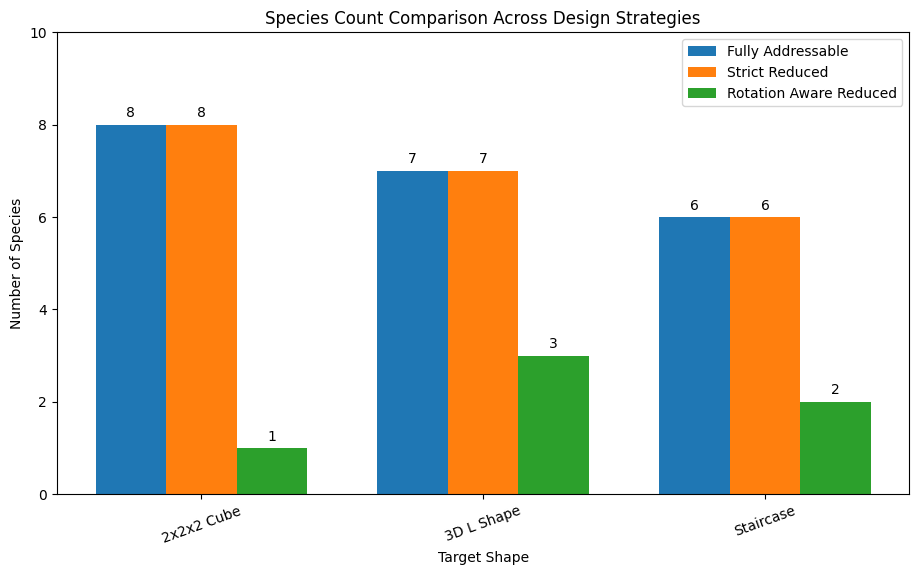

In [19]:
# ============================================================
# Step 11B: Visualize all three design strategies
# ============================================================

# What I am doing:
# I am plotting the number of species required under all three
# strategies for each target shape.

x = np.arange(len(three_strategy_df))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))

bars_full = ax.bar(
    x - width,
    three_strategy_df["fully_addressable_species"],
    width,
    label="Fully Addressable"
)

bars_strict = ax.bar(
    x,
    three_strategy_df["strict_reduced_species"],
    width,
    label="Strict Reduced"
)

bars_rotation = ax.bar(
    x + width,
    three_strategy_df["rotation_aware_reduced_species"],
    width,
    label="Rotation Aware Reduced"
)

ax.set_xlabel("Target Shape")
ax.set_ylabel("Number of Species")
ax.set_title("Species Count Comparison Across Design Strategies")
ax.set_xticks(x)
ax.set_xticklabels(three_strategy_df["shape"], rotation=20)
ax.legend()

# Add labels above each bar
for bars in [bars_full, bars_strict, bars_rotation]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.1,
            f"{int(height)}",
            ha="center",
            va="bottom"
        )

max_height = max(
    three_strategy_df["fully_addressable_species"].max(),
    three_strategy_df["strict_reduced_species"].max(),
    three_strategy_df["rotation_aware_reduced_species"].max()
)

ax.set_ylim(0, max_height + 2)

plt.show()

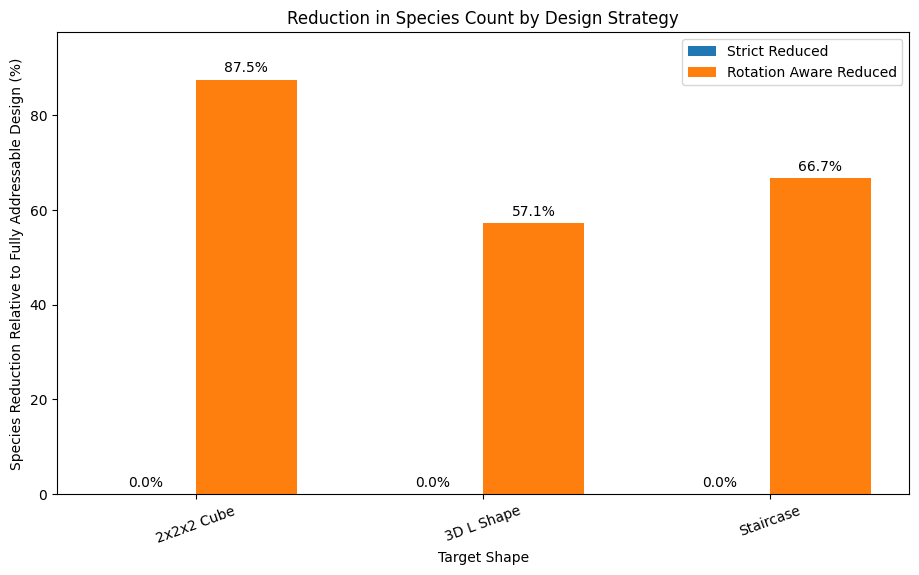

In [20]:
# ============================================================
# Step 11C: Visualize reduction percentage
# ============================================================

# What I am doing:
# I am comparing how much each reduced design strategy lowers
# the number of species relative to the fully addressable design.

x = np.arange(len(three_strategy_df))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars_strict_reduction = ax.bar(
    x - width / 2,
    three_strategy_df["strict_reduction_percent"],
    width,
    label="Strict Reduced"
)

bars_rotation_reduction = ax.bar(
    x + width / 2,
    three_strategy_df["rotation_aware_reduction_percent"],
    width,
    label="Rotation Aware Reduced"
)

ax.set_xlabel("Target Shape")
ax.set_ylabel("Species Reduction Relative to Fully Addressable Design (%)")
ax.set_title("Reduction in Species Count by Design Strategy")
ax.set_xticks(x)
ax.set_xticklabels(three_strategy_df["shape"], rotation=20)
ax.legend()

# Add labels above each bar
for bars in [bars_strict_reduction, bars_rotation_reduction]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.1f}%",
            ha="center",
            va="bottom"
        )

ax.set_ylim(
    0,
    max(
        10,
        three_strategy_df["rotation_aware_reduction_percent"].max() + 10
    )
)

plt.show()

## Step 12: Interpretation of Results

The results show that the choice of design strategy strongly affects the apparent complexity of a self assembly system.

The fully addressable design is the most direct strategy. Every voxel position receives its own unique species, and every bond receives its own unique complementary patch pair. This makes the target structure highly specific, but it also creates the largest number of unique building blocks.

The strict reduced design attempts to reduce complexity by grouping voxels with identical patch direction patterns. However, this method can be too restrictive because it treats globally different orientations as different species, even when the same physical cube could potentially be rotated and reused.

The rotation aware reduced design gives a more meaningful reduction. By recognizing that some local patch patterns are equivalent under cube rotations, it can group more voxel positions into the same reusable species. This is especially clear for symmetric structures such as the 2 x 2 x 2 cube, where many positions are geometrically similar under rotation.

Overall, this simplified model supports the central idea that a target structure does not always require one unique building block per position. Reusing rotated versions of similar building blocks can reduce design complexity while still preserving the overall target geometry.

## Important Limitations

This notebook is still a simplified educational model, not a full reproduction of the research pipeline.

The main limitations are:

1. The reduced designs are heuristic. They do not guarantee that the target structure is the only possible assembly.
2. The stochastic assembly test is target guided, so it does not fully search for off target structures, kinetic traps, or incorrect aggregates.
3. Patch colors and patch pairs are estimated using simplified direction based rules.
4. The model does not yet use a SAT solver to enforce formal inverse design constraints.
5. The model does not simulate physical patchy particle dynamics, binding flexibility, temperature effects, or molecular scale DNA nanostructures.
6. The notebook does not yet connect to oxDNA, oxView, or oxDNA level simulation tools.

Because of these limitations, the results should be interpreted as a conceptual and computational first step. The notebook helps explain the relationship between geometry, local connectivity, rotation equivalence, and building block reuse, but it does not yet prove that the reduced designs would assemble experimentally.

## Connection Back to the Paper

This notebook connects to the paper's larger idea of exploring design spaces between two extremes:

- A fully addressable design, where every component is unique
- A reduced or minimal complexity design, where fewer unique species are reused

The paper uses a more advanced pipeline involving SAT based inverse design, stochastic polycube assembly, patchy particle simulations, and DNA nanotechnology realization. In comparison, this notebook uses a simplified voxel model to understand the early computational logic behind those ideas.

The most important connection is that both approaches ask the same general question:

Can a target structure be designed using fewer unique building blocks than the number of positions in the final object?

This notebook shows a basic version of that idea by comparing fully addressable, strict reduced, and rotation aware reduced design strategies.

## Step 13: Future Work Roadmap

This notebook is intended as a second step after the initial minimal complexity self assembly model. The current version focuses on simplified 3D voxel based target shapes, local connectivity, and reduced building block strategies.

The next stage of the project would be to move from heuristic reduction toward more formal inverse design methods.

Possible future extensions include:

### 1. Extend to more complex 3D shapes

The current notebook uses small target shapes such as a 2 x 2 x 2 cube, a 3D L shape, and a staircase. Future work could test larger structures, hollow structures, wireframe structures, and biologically inspired geometries.

### 2. Add a basic constraint solver

A future version could implement a simple constraint based solver that searches for valid species and patch assignments automatically. This would be a first step toward the SAT based design approach used in the research paper.

### 3. Test for off target assembly

The current stochastic assembly test is target guided. A stronger model would allow blocks to attach in any compatible way and then check whether incorrect aggregates or unbounded structures appear.

### 4. Compare multiple reduced design strategies

This notebook compares fully addressable, strict reduced, and rotation aware reduced strategies. Future work could compare additional strategies such as greedy species merging, symmetry based grouping, and staged assembly.

### 5. Study SAT based design more directly

The paper formulates the inverse design problem as a Boolean satisfiability problem. A future notebook could introduce Boolean variables for species, patch colors, orientations, and compatibility rules.

### 6. Explore DNA and RNA nanotechnology tools

The model could eventually be connected to existing tools such as oxDNA, oxView, or related DNA nanotechnology design software. This would help bridge the gap between abstract voxel based models and molecular scale implementation.

### 7. Connect to sustainability applications

Reduced complexity self assembly may have sustainability relevance because fewer unique components could reduce material use, fabrication complexity, and experimental cost. Future versions could discuss possible applications in environmental sensing, programmable materials, or low resource manufacturing.

In [21]:
# ============================================================
# Step 13: Create a future work roadmap table
# ============================================================

# What I am doing:
# I am summarizing the future work directions in a structured table.
# This makes the next steps easier to discuss in a meeting or include
# in a GitHub README.

future_work_rows = [
    {
        "future_direction": "More complex 3D shapes",
        "purpose": "Test whether the design strategies scale beyond small examples",
        "difficulty": "Medium",
        "connection_to_current_notebook": "Uses the same voxel and adjacency representation"
    },
    {
        "future_direction": "Basic constraint solver",
        "purpose": "Move from heuristic grouping toward automated inverse design",
        "difficulty": "Medium to High",
        "connection_to_current_notebook": "Would replace manual reduction rules with formal constraints"
    },
    {
        "future_direction": "Off target assembly testing",
        "purpose": "Check whether reduced designs create unwanted structures",
        "difficulty": "High",
        "connection_to_current_notebook": "Improves the simplified stochastic assembly test"
    },
    {
        "future_direction": "Multiple reduction strategies",
        "purpose": "Compare design choices beyond strict and rotation aware grouping",
        "difficulty": "Medium",
        "connection_to_current_notebook": "Builds on the three strategy comparison table"
    },
    {
        "future_direction": "SAT based design",
        "purpose": "Represent species, patches, orientations, and compatibility as Boolean constraints",
        "difficulty": "High",
        "connection_to_current_notebook": "Directly extends the inverse design logic"
    },
    {
        "future_direction": "oxDNA and oxView exploration",
        "purpose": "Connect abstract cube based designs to DNA nanotechnology simulation tools",
        "difficulty": "High",
        "connection_to_current_notebook": "Moves from conceptual design to molecular scale modeling"
    },
    {
        "future_direction": "Sustainable materials connection",
        "purpose": "Discuss how reduced component complexity could support resource efficient design",
        "difficulty": "Low to Medium",
        "connection_to_current_notebook": "Connects species reduction to material and fabrication efficiency"
    }
]

future_work_df = pd.DataFrame(future_work_rows)

display(future_work_df)

,future_direction,purpose,difficulty,connection_to_current_notebook
0,More complex 3D shapes,Test whether the design strategies scale beyon...,Medium,Uses the same voxel and adjacency representation
1,Basic constraint solver,Move from heuristic grouping toward automated ...,Medium to High,Would replace manual reduction rules with form...
2,Off target assembly testing,Check whether reduced designs create unwanted ...,High,Improves the simplified stochastic assembly test
3,Multiple reduction strategies,Compare design choices beyond strict and rotat...,Medium,Builds on the three strategy comparison table
4,SAT based design,"Represent species, patches, orientations, and ...",High,Directly extends the inverse design logic
5,oxDNA and oxView exploration,Connect abstract cube based designs to DNA nan...,High,Moves from conceptual design to molecular scal...
6,Sustainable materials connection,Discuss how reduced component complexity could...,Low to Medium,Connects species reduction to material and fab...
